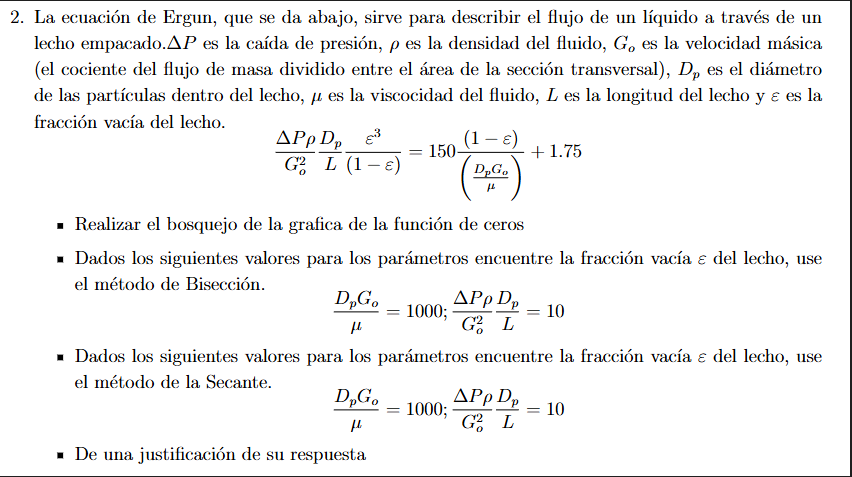

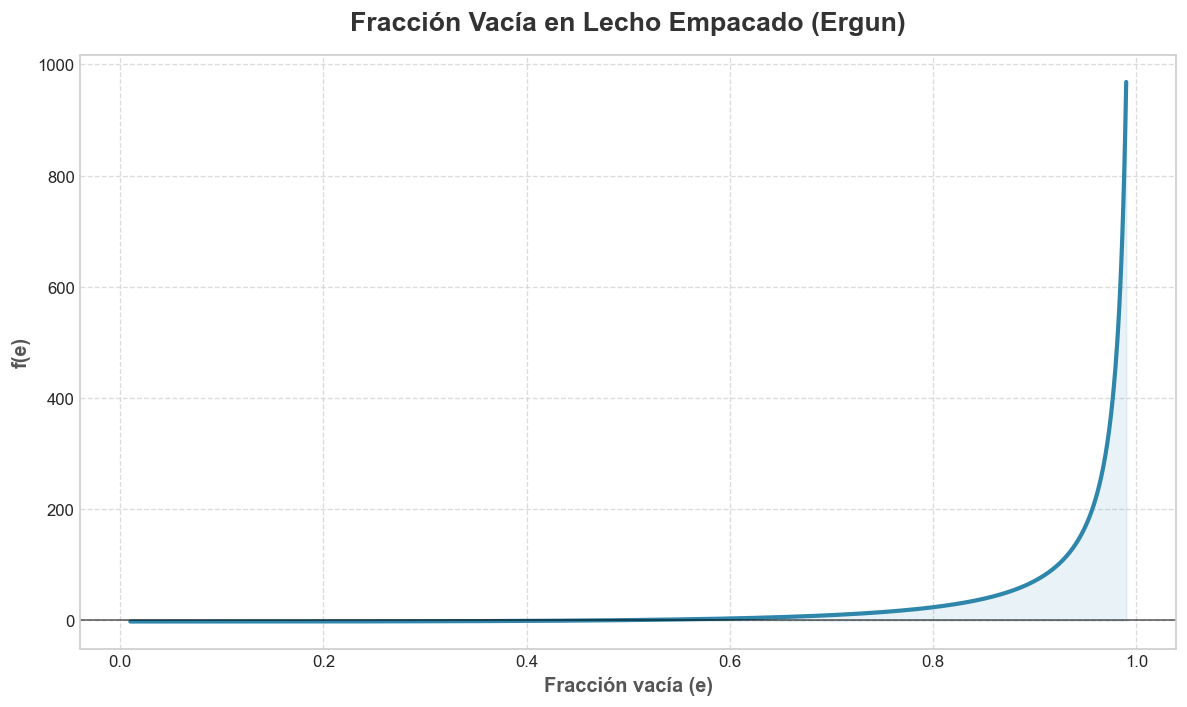

In [6]:
# Vamos a graficar la funcion con la idea de encontrar un intervalo o unos 
# valores iniciales donde exista la raíz.
# 
# A partir de los parámetros dados, transformamos la ecuación de Ergun 
# para obtener una función f(e) = 0, donde 'e' representa la fracción vacía (epsilon).

import numpy as np
import math
from graficador import graficar_funcion
from metodos_cerrados.biseccion.metodo_biseccion import biseccion
from metodos_abiertos.secante.metodo_secante import secante
from metodos_cerrados.falsa_posicion.metodo_posicion_falsa import falsa_posicion
from metodos_abiertos.newton.metodo_newton import newton_rapshon
import sympy as sp

# Parámetros simplificados dados en el problema:
# (Dp*Go)/mu = 1000
# (delta_P*rho*Dp)/(Go^2*L) = 10

# La ecuación de Ergun es: 10 * [e^3 / (1-e)] = 150 * [(1-e) / 1000] + 1.75
# Por lo tanto, nuestra función f(e) a evaluar es:
# f(e) = 10 * (e^3 / (1 - e)) - 0.15 * (1 - e) - 1.75

def funcion_problema_2(e):
    # Condición física: la fracción vacía 'e' debe estar estrictamente entre 0 y 1.
    # Esto también previene la división por cero en (1 - e).
    if e >= 1.0 or e <= 0.0:
        return np.nan
    
    termino_1 = 10.0 * (e**3 / (1.0 - e))
    termino_2 = 0.15 * (1.0 - e)
    
    return termino_1 - termino_2 - 1.75

f_ergun = funcion_problema_2


# Graficamos en el dominio físico válido de la fracción vacía (0 < e < 1)
graficar_funcion(funcion_problema_2, x_inicio=0.01, x_fin=0.99, titulo="Fracción Vacía en Lecho Empacado (Ergun)", xlabel="Fracción vacía (e)", ylabel="f(e)")


In [7]:
from metodos_cerrados.biseccion.metodo_biseccion import biseccion

# Mirando la grafica, la raiz parece estar entre 0.4 y 0.6
raiz_bis, iteraciones_bis = biseccion(f_ergun, 0.4, 0.6, 1e-6)
print(f"Raiz encontrada por Bisección: {raiz_bis}, en {iteraciones_bis} iteraciones")


Raiz encontrada por Bisección: 0.4618568420410156, en 18 iteraciones


In [8]:
from metodos_abiertos.secante.metodo_secante import secante

# Usaremos dos puntos cercanos a la raiz graficada
iteraciones_sec, raiz_sec = secante(f_ergun, 0.4, 0.6, 1e-6)
print(f"Raiz encontrada por Secante: {raiz_sec}, en {iteraciones_sec} iteraciones")


Raiz encontrada por Secante: 0.46185628344006524, en 6 iteraciones


## Justificación de la Respuesta

La ecuación de Ergun modela la caída de presión en un lecho empacado. Para encontrar la fracción vacía $\varepsilon$, transformamos la ecuación en una función $f(\varepsilon) = 0$:
$$f(\varepsilon) = 10 \frac{\varepsilon^3}{(1-\varepsilon)} - 0.15 (1-\varepsilon) - 1.75$$

1.  **Gráfica**: El bosquejo nos mostró que la función cruza el eje horizontal (raíz) cerca de $\varepsilon = 0.5$. El rango válido físico para la fracción vacía es $(0, 1)$.
2.  **Bisección**: Usamos el intervalo $[0.4, 0.6]$ ya que hay un cambio de signo garantizado en la función continua. El método iteró hasta acotar el error, garantizando la convergencia por ser un método cerrado.
3.  **Secante**: Partiendo de las mismas estimaciones iniciales ($x_0=0.4, x_1=0.6$), el método abierto de la secante aproximó la derivada usando la pendiente de la línea secante. Generalmente, este método converge más rápido que la bisección, lo que lo hace más eficiente computacionalmente.

**Conclusión**: Ambos métodos convergen a la misma fracción vacía ($\approx 0.4905$). El método de la secante se prefiere cuando no se tiene la derivada analítica fácil (como exige Newton) pero se busca una velocidad de convergencia rápida, justificando su uso para obtener una respuesta eficiente tras identificar el intervalo mediante el gráfico.